## **Heart Disease Prediction**

  Cardiovascular diseases are among the leading causes of mortality worldwide. Early and accurate detection of heart disease can significantly improve patient outcomes and reduce healthcare costs. With the increasing availability of clinical and diagnostic data, machine learning techniques can be effectively utilized to assist healthcare professionals in predicting the presence of heart disease

# 1.Importing essential libraries

* Let's first import all the necessary libraries. I'll use `numpy` and `pandas` to start with. For visualization, I will use `pyplot` subpackage of `matplotlib`. For implementing Machine Learning models and processing of data, I will use the `sklearn` library.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2.Importing the data set

In [ ]:
data=pd.read_csv('/content/values.csv')

In [ ]:
data

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [ ]:
data=data.rename(columns={
    'slope_of_peak_exercise_st_segment': 'st_slope',
    'thal': 'thalassemia',
    'resting_blood_pressure': 'rest_bp',
    'chest_pain_type': 'cp_type',
    'num_major_vessels': 'num_vessels',
    'fasting_blood_sugar_gt_120_mg_per_dl': 'fbs_high',
    'resting_ekg_results': 'rest_ecg',
    'serum_cholesterol_mg_per_dl': 'cholesterol',
    'oldpeak_eq_st_depression': 'oldpeak',
    'max_heart_rate_achieved': 'max_hr',
    'exercise_induced_angina': 'ex_angina'
})

# Basic checks



shape of the dataset

In [ ]:
data.shape

(180, 14)

type of the data set

In [ ]:
type(data)

pandas.core.frame.DataFrame

description

In [ ]:
data.describe()

,st_slope,rest_bp,cp_type,num_vessels,fbs_high,rest_ecg,cholesterol,oldpeak,sex,age,max_hr,ex_angina
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000


#info

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   180 non-null    object 
 1   st_slope     180 non-null    int64  
 2   thalassemia  180 non-null    object 
 3   rest_bp      180 non-null    int64  
 4   cp_type      180 non-null    int64  
 5   num_vessels  180 non-null    int64  
 6   fbs_high     180 non-null    int64  
 7   rest_ecg     180 non-null    int64  
 8   cholesterol  180 non-null    int64  
 9   oldpeak      180 non-null    float64
 10  sex          180 non-null    int64  
 11  age          180 non-null    int64  
 12  max_hr       180 non-null    int64  
 13  ex_angina    180 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 19.8+ KB


checking for missing values

In [ ]:
data.isnull().sum()

,0
patient_id,0
st_slope,0
thalassemia,0
rest_bp,0
cp_type,0
num_vessels,0
fbs_high,0
rest_ecg,0
cholesterol,0
oldpeak,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.columns

Index(['patient_id', 'st_slope', 'thalassemia', 'rest_bp', 'cp_type',
       'num_vessels', 'fbs_high', 'rest_ecg', 'cholesterol', 'oldpeak', 'sex',
       'age', 'max_hr', 'ex_angina'],
      dtype='object')

dtypes

In [ ]:
data.dtypes

,0
patient_id,object
st_slope,int64
thalassemia,object
rest_bp,int64
cp_type,int64
num_vessels,int64
fbs_high,int64
rest_ecg,int64
cholesterol,int64
oldpeak,float64


In [ ]:
data['ex_angina'].describe()

,ex_angina
count,180.000000
mean,0.316667
std,0.466474
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
data['ex_angina'].unique()

array([0, 1])

In [ ]:
data.ex_angina.value_counts()

,count
ex_angina,
0,123
1,57


Clearely,this is a classification problem,with the target variables having values 0 and 1


# checking correlation between columns

In [ ]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])
print(numeric_data.corr()["ex_angina"].abs().sort_values(ascending=False))

ex_angina      1.000000
max_hr         0.365065
cp_type        0.346266
sex            0.251096
oldpeak        0.249167
st_slope       0.225459
num_vessels    0.153407
rest_bp        0.123397
cholesterol    0.083139
age            0.081811
rest_ecg       0.037773
fbs_high       0.005956
Name: ex_angina, dtype: float64


this shows that most columns are moderately correlated with exercise_induced_angina,but fasting_blood_sugar gt_120_mg_per_dl is weekly correlated

# Exploratory data analysis

# univariant
* hist plot is used to check distribution of data
* count plot is used to check wheather the data is balanced or not

In [ ]:
#check wheather the data is balanced or not

<Axes: xlabel='ex_angina', ylabel='count'>

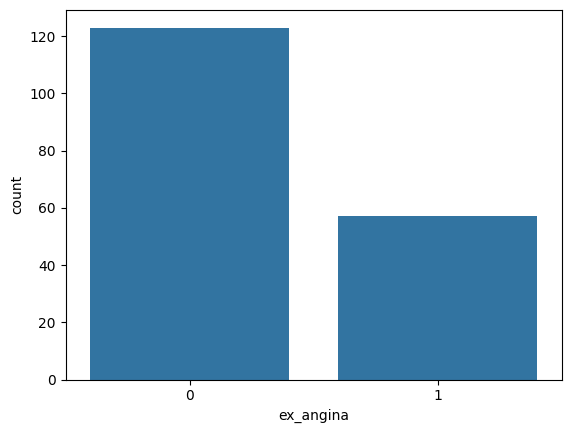

In [ ]:
sns.countplot(x='ex_angina',data=data)

# Insights
* data is imbalanced since we have more records related to exercise induced angina is present and no exercise induced angina

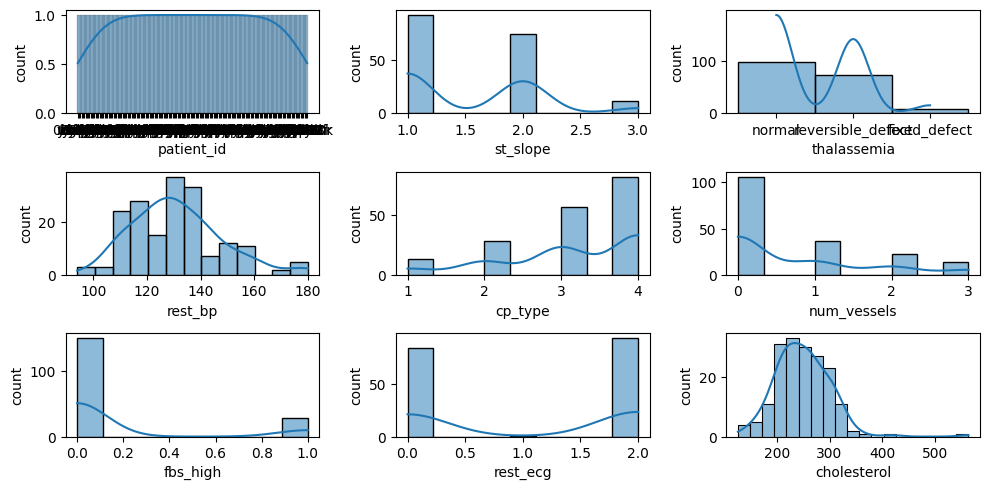

In [ ]:
#check for distribution of dta
plt.figure(figsize=(10,5),facecolor='white')
plotnumber=1
for column in data:
  if plotnumber<=9:
    ax=plt.subplot(3,3,plotnumber)
    sns.histplot(x=data[column],kde=True)
    plt.xlabel(column,fontsize=10)
    plt.ylabel('count',fontsize=10)
  plotnumber+=1
plt.tight_layout()

# insights
* Resting blood pressure and serm cholesterol mg per dl represents normal distribution

## Bivariant

In [ ]:
#Analysing the max_heart_rate_achieved feature
data['max_hr'].unique()

array([170, 158, 162, 181, 145, 150, 157, 112, 140, 151, 178, 152, 182,
       126, 175, 144, 202, 147, 142, 138, 143, 115, 159, 184, 155, 123,
       168, 114, 154, 165, 186, 173, 163, 121, 161, 137, 172, 130, 167,
       141, 166, 125, 103, 120, 132, 169, 179,  99, 177, 160, 156, 109,
       139, 134, 113, 149, 174, 131, 148, 153, 133, 122, 105, 106, 192,
       108,  96, 171, 180, 188, 111,  97, 117])

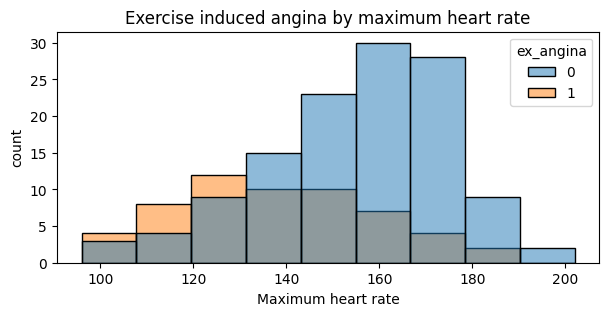

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(data=data,x='max_hr',hue='ex_angina')
plt.title('Exercise induced angina by maximum heart rate')
plt.xlabel('Maximum heart rate')
plt.ylabel('count')
plt.show()

In [ ]:
#Analysing the chest_pain_type feature
data['cp_type'].unique()

array([2, 3, 4, 1])

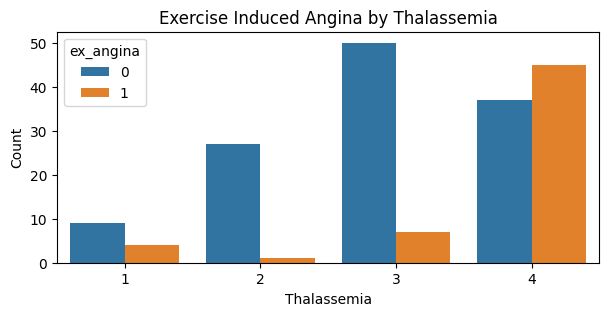

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(data=data, x='cp_type', hue='ex_angina')
plt.title('Exercise Induced Angina by Thalassemia')
plt.xlabel('Thalassemia')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the sex feature
data['sex'].unique()

array([1, 0])

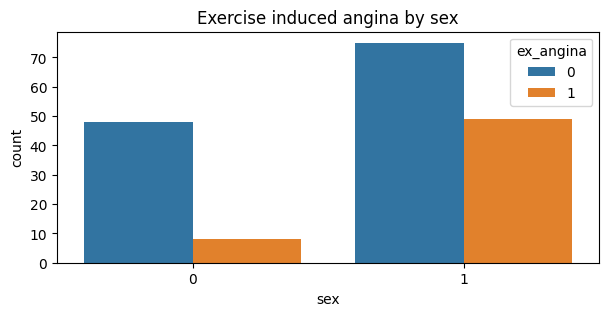

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(data=data,x='sex',hue='ex_angina')
plt.title('Exercise induced angina by sex')
plt.xlabel('sex')
plt.ylabel('count')
plt.show()


In [ ]:
#Analysing the resting_blood_pressure feature
data['rest_bp'].unique()

array([128, 110, 125, 152, 178, 130, 150, 170, 120, 140, 138, 144, 136,
       160, 108, 106, 156, 180, 112, 122, 124, 135, 105, 115, 126, 172,
       145, 118, 134, 100, 155, 132, 102,  94, 117, 142])

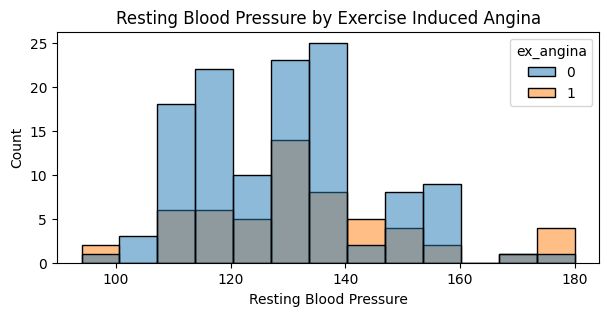

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(data=data, x='rest_bp', hue='ex_angina')
plt.title('Resting Blood Pressure by Exercise Induced Angina')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the oldpeak_eq_st_depression feature
data['oldpeak'].unique()

array([0. , 1.6, 4.2, 2.6, 0.6, 3.4, 0.4, 0.2, 3.8, 0.9, 1.4, 0.1, 0.3,
       2.3, 1.5, 3. , 2. , 1. , 3.1, 2.5, 0.8, 2.4, 1.8, 1.9, 2.8, 1.2,
       0.5, 2.2, 1.3, 1.1, 0.7, 3.2, 5.6, 6.2])

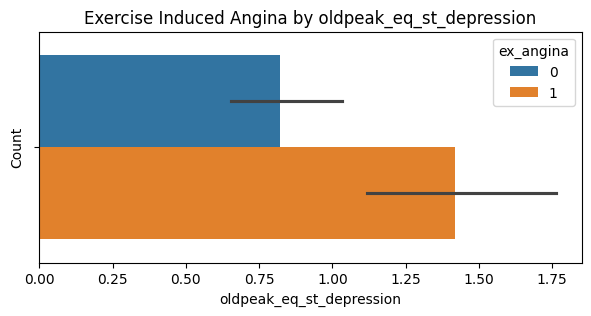

In [ ]:
plt.figure(figsize=(7,3))
sns.barplot(data=data, x='oldpeak', hue='ex_angina')
plt.title('Exercise Induced Angina by oldpeak_eq_st_depression')
plt.xlabel('oldpeak_eq_st_depression')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the serum_cholesterol_mg_per_dl feature
data['cholesterol'].unique()

array([308, 214, 304, 223, 270, 180, 258, 276, 326, 219, 302, 226, 335,
       236, 231, 200, 234, 253, 204, 319, 233, 228, 245, 211, 303, 205,
       185, 175, 225, 203, 325, 230, 222, 126, 209, 269, 255, 243, 252,
       265, 417, 267, 261, 149, 281, 311, 315, 330, 256, 239, 295, 197,
       564, 305, 283, 160, 254, 282, 322, 250, 188, 220, 199, 215, 218,
       196, 266, 229, 259, 268, 177, 168, 262, 271, 299, 293, 141, 277,
       212, 321, 294, 313, 232, 289, 213, 274, 263, 244, 298, 172, 353,
       210, 192, 246, 286, 360, 174, 227, 248, 224, 300, 235, 217, 193,
       167, 216, 195, 309, 273, 198, 290, 275, 206, 164, 207, 249, 327,
       201])

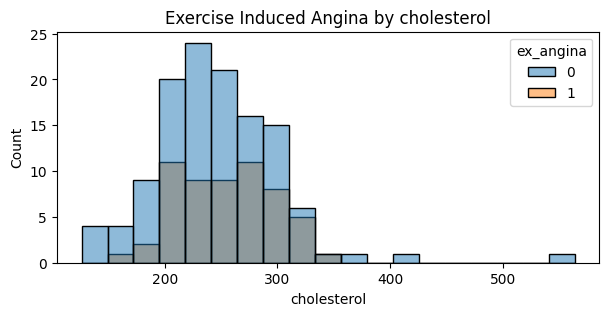

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(data=data, x='cholesterol', hue='ex_angina')
plt.title('Exercise Induced Angina by cholesterol')
plt.xlabel('cholesterol')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the age feature
data['age'].unique()

array([45, 54, 77, 40, 59, 42, 60, 57, 50, 66, 64, 38, 29, 58, 71, 52, 67,
       70, 68, 51, 41, 65, 53, 48, 62, 74, 61, 63, 46, 43, 56, 44, 35, 55,
       49, 47, 37, 69, 39, 34])

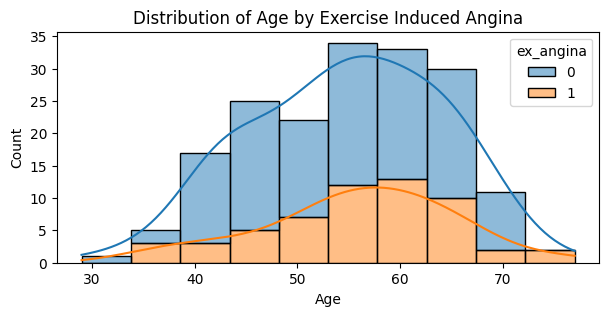

In [ ]:
plt.figure(figsize=(7,3))
sns.histplot(data=data, x='age', hue='ex_angina', kde=True, multiple='stack')
plt.title('Distribution of Age by Exercise Induced Angina')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [ ]:
data.columns

Index(['patient_id', 'st_slope', 'thalassemia', 'rest_bp', 'cp_type',
       'num_vessels', 'fbs_high', 'rest_ecg', 'cholesterol', 'oldpeak', 'sex',
       'age', 'max_hr', 'ex_angina'],
      dtype='object')

In [ ]:
#Analysing the num_major_vessels feature
data['num_vessels'].unique()

array([0, 3, 2, 1])

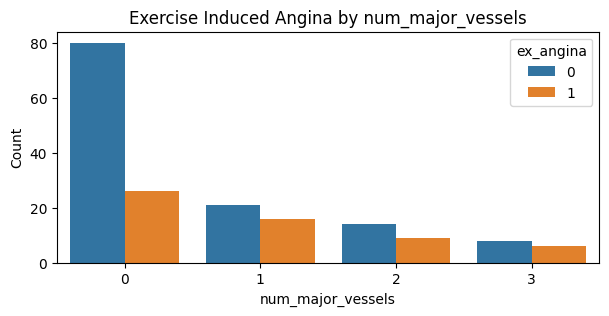

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(data=data, x='num_vessels', hue='ex_angina')
plt.title('Exercise Induced Angina by num_major_vessels')
plt.xlabel('num_major_vessels')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the slope_of_peak_exercise_st_segment feature
data['st_slope'].unique()

array([1, 2, 3])

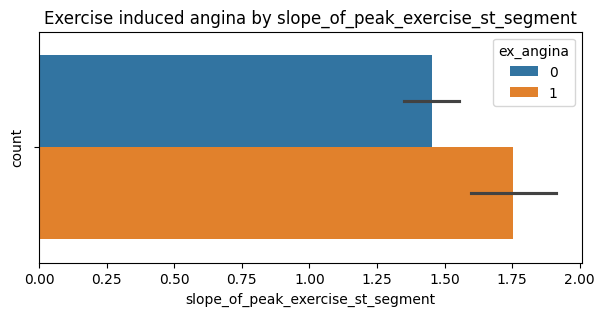

In [ ]:
plt.figure(figsize=(7,3))
sns.barplot(data=data,x='st_slope',hue='ex_angina')
plt.title('Exercise induced angina by slope_of_peak_exercise_st_segment')
plt.xlabel('slope_of_peak_exercise_st_segment')
plt.ylabel('count')
plt.show()

In [ ]:
#Analysing resting_ekg_results feature
data['rest_ecg'].unique()

array([2, 0, 1])

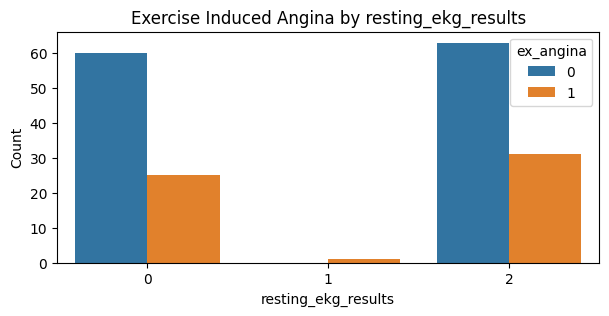

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(data=data, x='rest_ecg', hue='ex_angina')
plt.title('Exercise Induced Angina by resting_ekg_results')
plt.xlabel('resting_ekg_results')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the thal feature
data['thalassemia'].unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

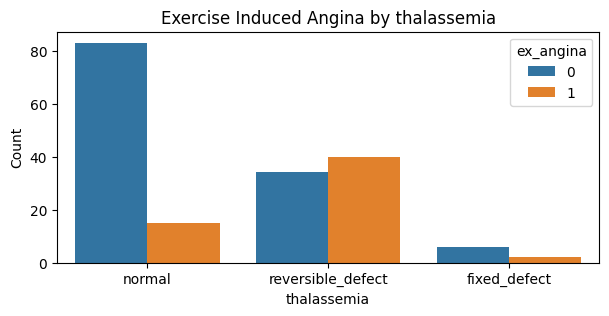

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(data=data, x='thalassemia', hue='ex_angina')
plt.title('Exercise Induced Angina by thalassemia')
plt.xlabel('thalassemia')
plt.ylabel('Count')
plt.show()

In [ ]:
#Analysing the fasting_blood_sugar_gt_120_mg_per_dl feature
data['fbs_high'].unique()

array([0, 1])

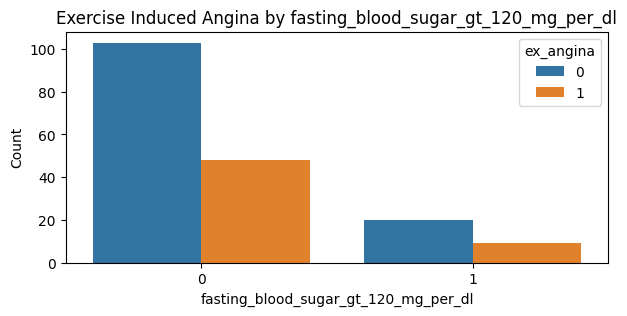

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(data=data, x='fbs_high', hue='ex_angina')
plt.title('Exercise Induced Angina by fasting_blood_sugar_gt_120_mg_per_dl')
plt.xlabel('fasting_blood_sugar_gt_120_mg_per_dl')
plt.ylabel('Count')
plt.show()

### Finding Outliers using the IQR Method

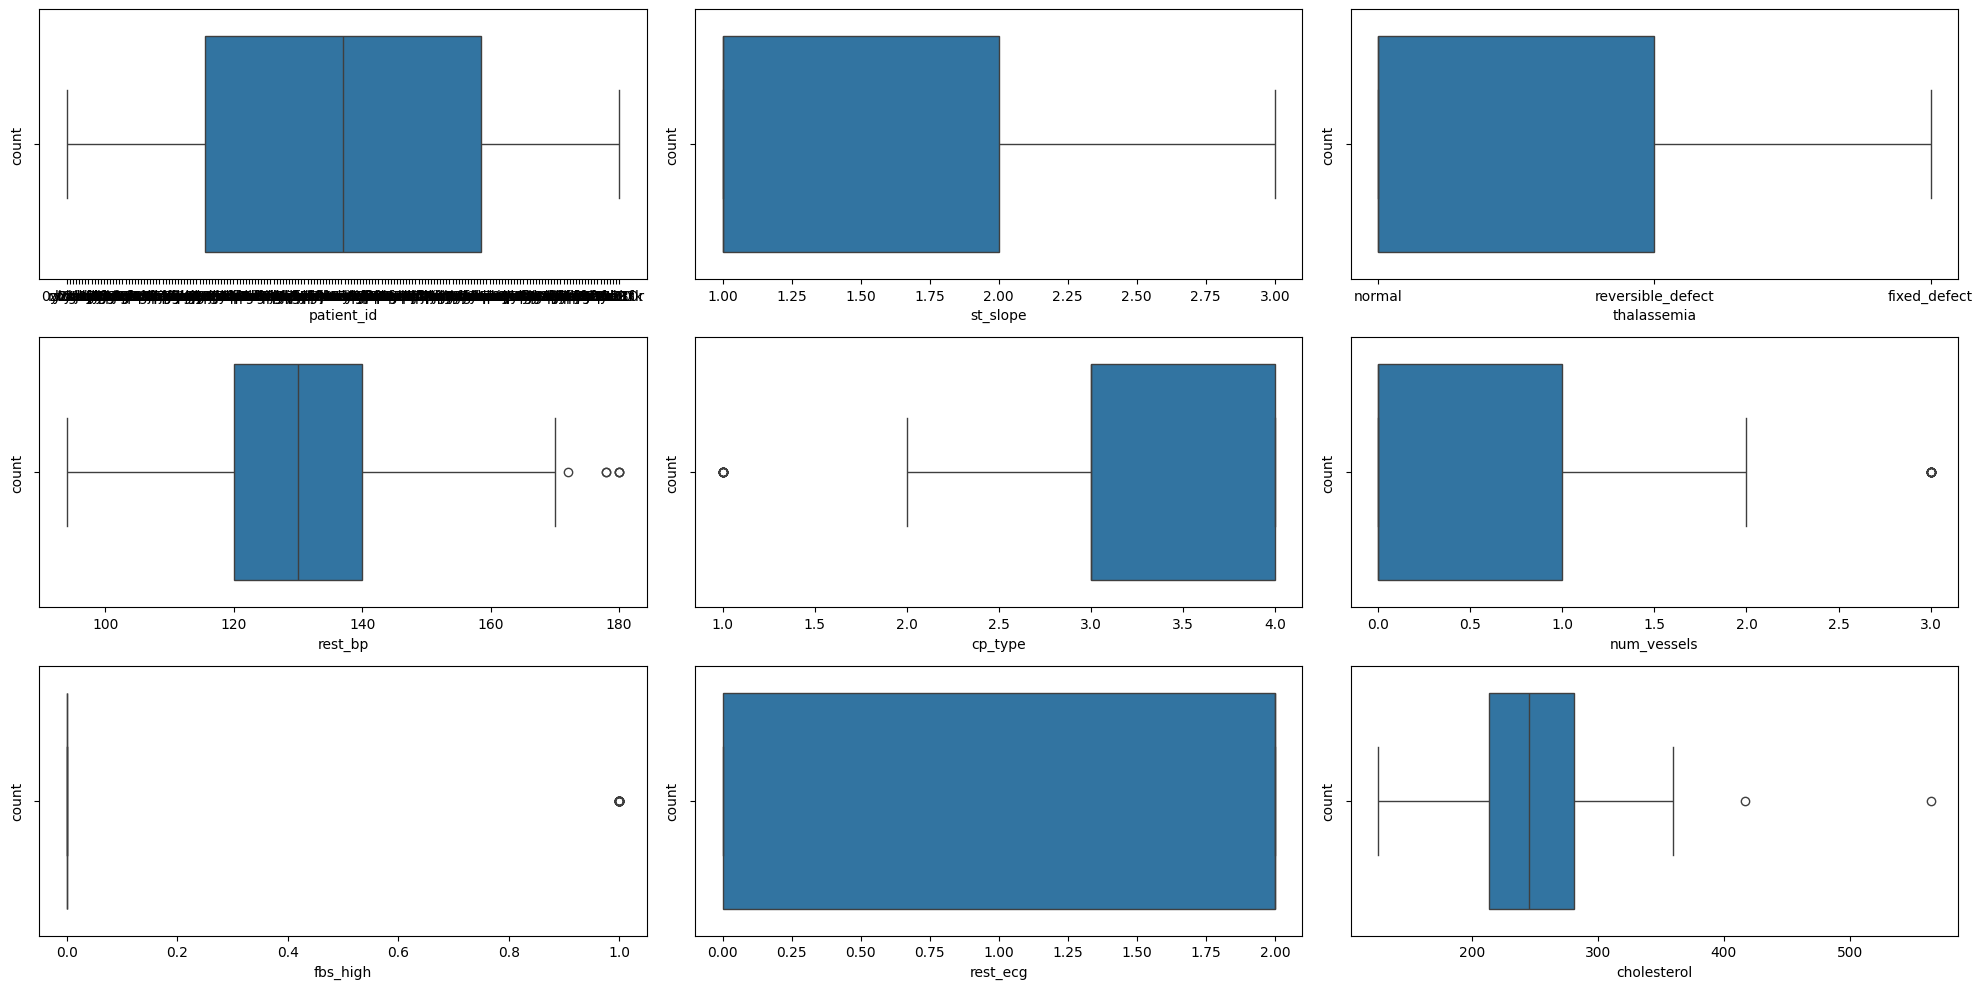

In [ ]:
plt.figure(figsize=(20,10),facecolor='white')
plotnumber=1
for column in data:
  if plotnumber<=9:
    ax=plt.subplot(3,3,plotnumber)
    sns.boxplot(x=data[column])
    plt.xlabel(column,fontsize=10)
    plt.ylabel('count',fontsize=10)
  plotnumber+=1
plt.tight_layout()

## IQR
* find Q1 and Q3
* find IQR=Q3-Q1
* find lower limit and upper limit
* lower_limit=Q1-1.5*IQR
* upper_limit=Q3+1.5*IQR
* Find records/values which are greater than upper limit and less than lower limit

In [ ]:
# find Q1 and Q3
Q1=data['rest_bp'].quantile(0.25)
print("lower quartile",Q1)
Q3=data['rest_bp'].quantile(0.75)
print("upper quartile",Q3)

lower quartile 120.0
upper quartile 140.0


In [ ]:
#find IQR
IQR=Q3-Q1
IQR

np.float64(20.0)

In [ ]:
#find lower limit and upper limit
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print("lower limit",lower_limit)
print("upper limit",upper_limit)

lower limit 90.0
upper limit 170.0


In [ ]:
#find values about upper limit
data.loc[data['rest_bp']>upper_limit]

,patient_id,st_slope,thalassemia,rest_bp,cp_type,num_vessels,fbs_high,rest_ecg,cholesterol,oldpeak,sex,age,max_hr,ex_angina
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
33,0n5fu0,1,normal,180,4,0,0,0,325,0.0,0,64,154,1
72,qwj1yf,1,reversible_defect,172,3,0,1,0,199,0.5,1,52,162,0
75,4v0q7o,2,reversible_defect,178,4,2,1,0,228,1.0,0,66,165,1
113,sqddbc,2,reversible_defect,180,3,0,1,2,274,1.6,1,68,150,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1


In [ ]:
len(data.loc[data['rest_bp']>upper_limit])/len(data)

0.03333333333333333

In [ ]:
#find values below lower limit
data.loc[data['rest_bp']<lower_limit]

,patient_id,st_slope,thalassemia,rest_bp,cp_type,num_vessels,fbs_high,rest_ecg,cholesterol,oldpeak,sex,age,max_hr,ex_angina


In [ ]:
#how to handle outliers
#since data is not normal will replace outliers with median
data.loc[data['rest_bp']>upper_limit,"rest_bp"]=data['rest_bp'].median()

<Axes: xlabel='rest_bp'>

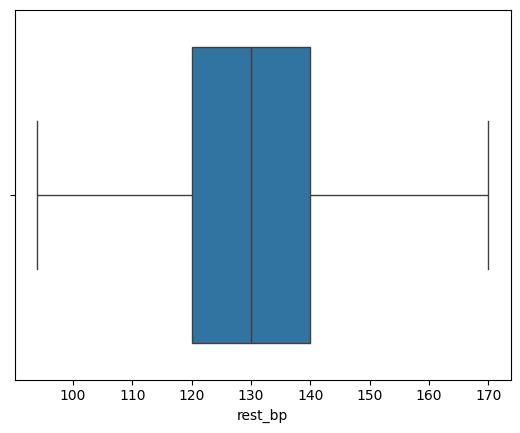

In [ ]:
#check are there any outliers in rest_bp
sns.boxplot(data=data,x='rest_bp')

lower quartile 3.0
upper quartile 3.0
lower limit 3.0
upper limit 3.0


<Axes: xlabel='cp_type'>

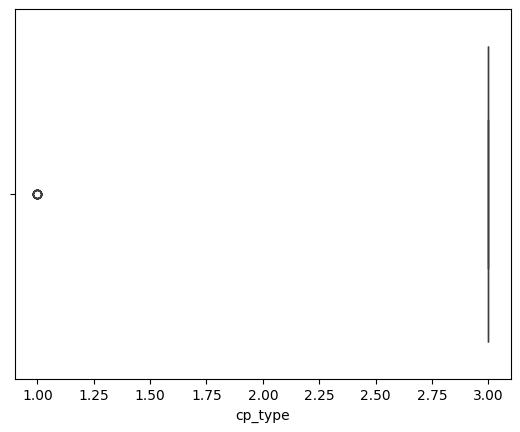

In [ ]:
#handle outliers for cp_type
Q1=data['cp_type'].quantile(0.25)
print("lower quartile",Q1)
Q3=data['cp_type'].quantile(0.75)
print("upper quartile",Q3)
#find IQR
IQR=Q3-Q1
IQR

lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print("lower limit",lower_limit)
print("upper limit",upper_limit)

len(data.loc[data['cp_type']>lower_limit])/len(data)
data.loc[data['cp_type']<upper_limit]
data.loc[data['cp_type']>lower_limit,"cp_type"]=data['cp_type'].median()

sns.boxplot(data=data,x='cp_type')

In [ ]:
Q1 = data['cp_type'].quantile(0.25)
Q3 = data['cp_type'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['cp_type'] >= lower) & (data['cp_type'] <= upper)]

<Axes: xlabel='cp_type'>

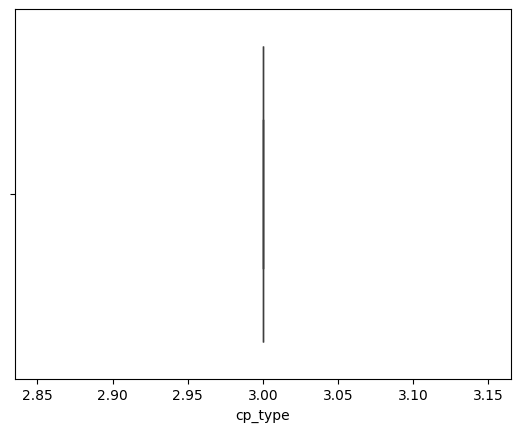

In [ ]:
sns.boxplot(data=data,x='cp_type')

In [ ]:
Q1 = data['fbs_high'].quantile(0.25)
Q3 = data['fbs_high'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['fbs_high'] >= lower) & (data['fbs_high'] <= upper)]

<Axes: xlabel='cp_type'>

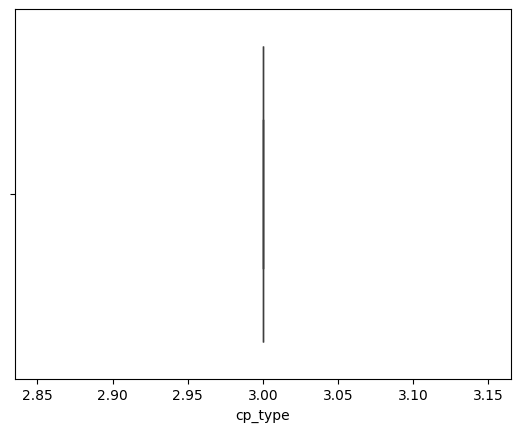

In [ ]:
sns.boxplot(data=data,x='cp_type')

In [ ]:
#handle outlilers for num_vessels
Q1=data['num_vessels'].quantile(0.25)
print("lower quartile",Q1)
Q3=data['num_vessels'].quantile(0.75)
print("upper quartile",Q3)
#find IQR
IQR=Q3-Q1
IQR
#find lower limit and upper limit
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print("lower limit",lower_limit)
print("upper limit",upper_limit)

len(data.loc[data['num_vessels']>upper_limit])/len(data)
data.loc[data['num_vessels']<lower_limit]
data.loc[data['num_vessels']>upper_limit,"num_vessels"]=data['num_vessels'].median()

lower quartile 0.0
upper quartile 1.0
lower limit -1.5
upper limit 2.5


<Axes: xlabel='num_vessels'>

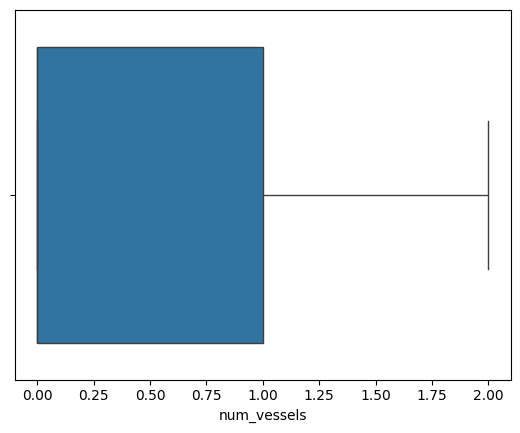

In [ ]:
sns.boxplot(data=data,x='num_vessels')

# multivariant

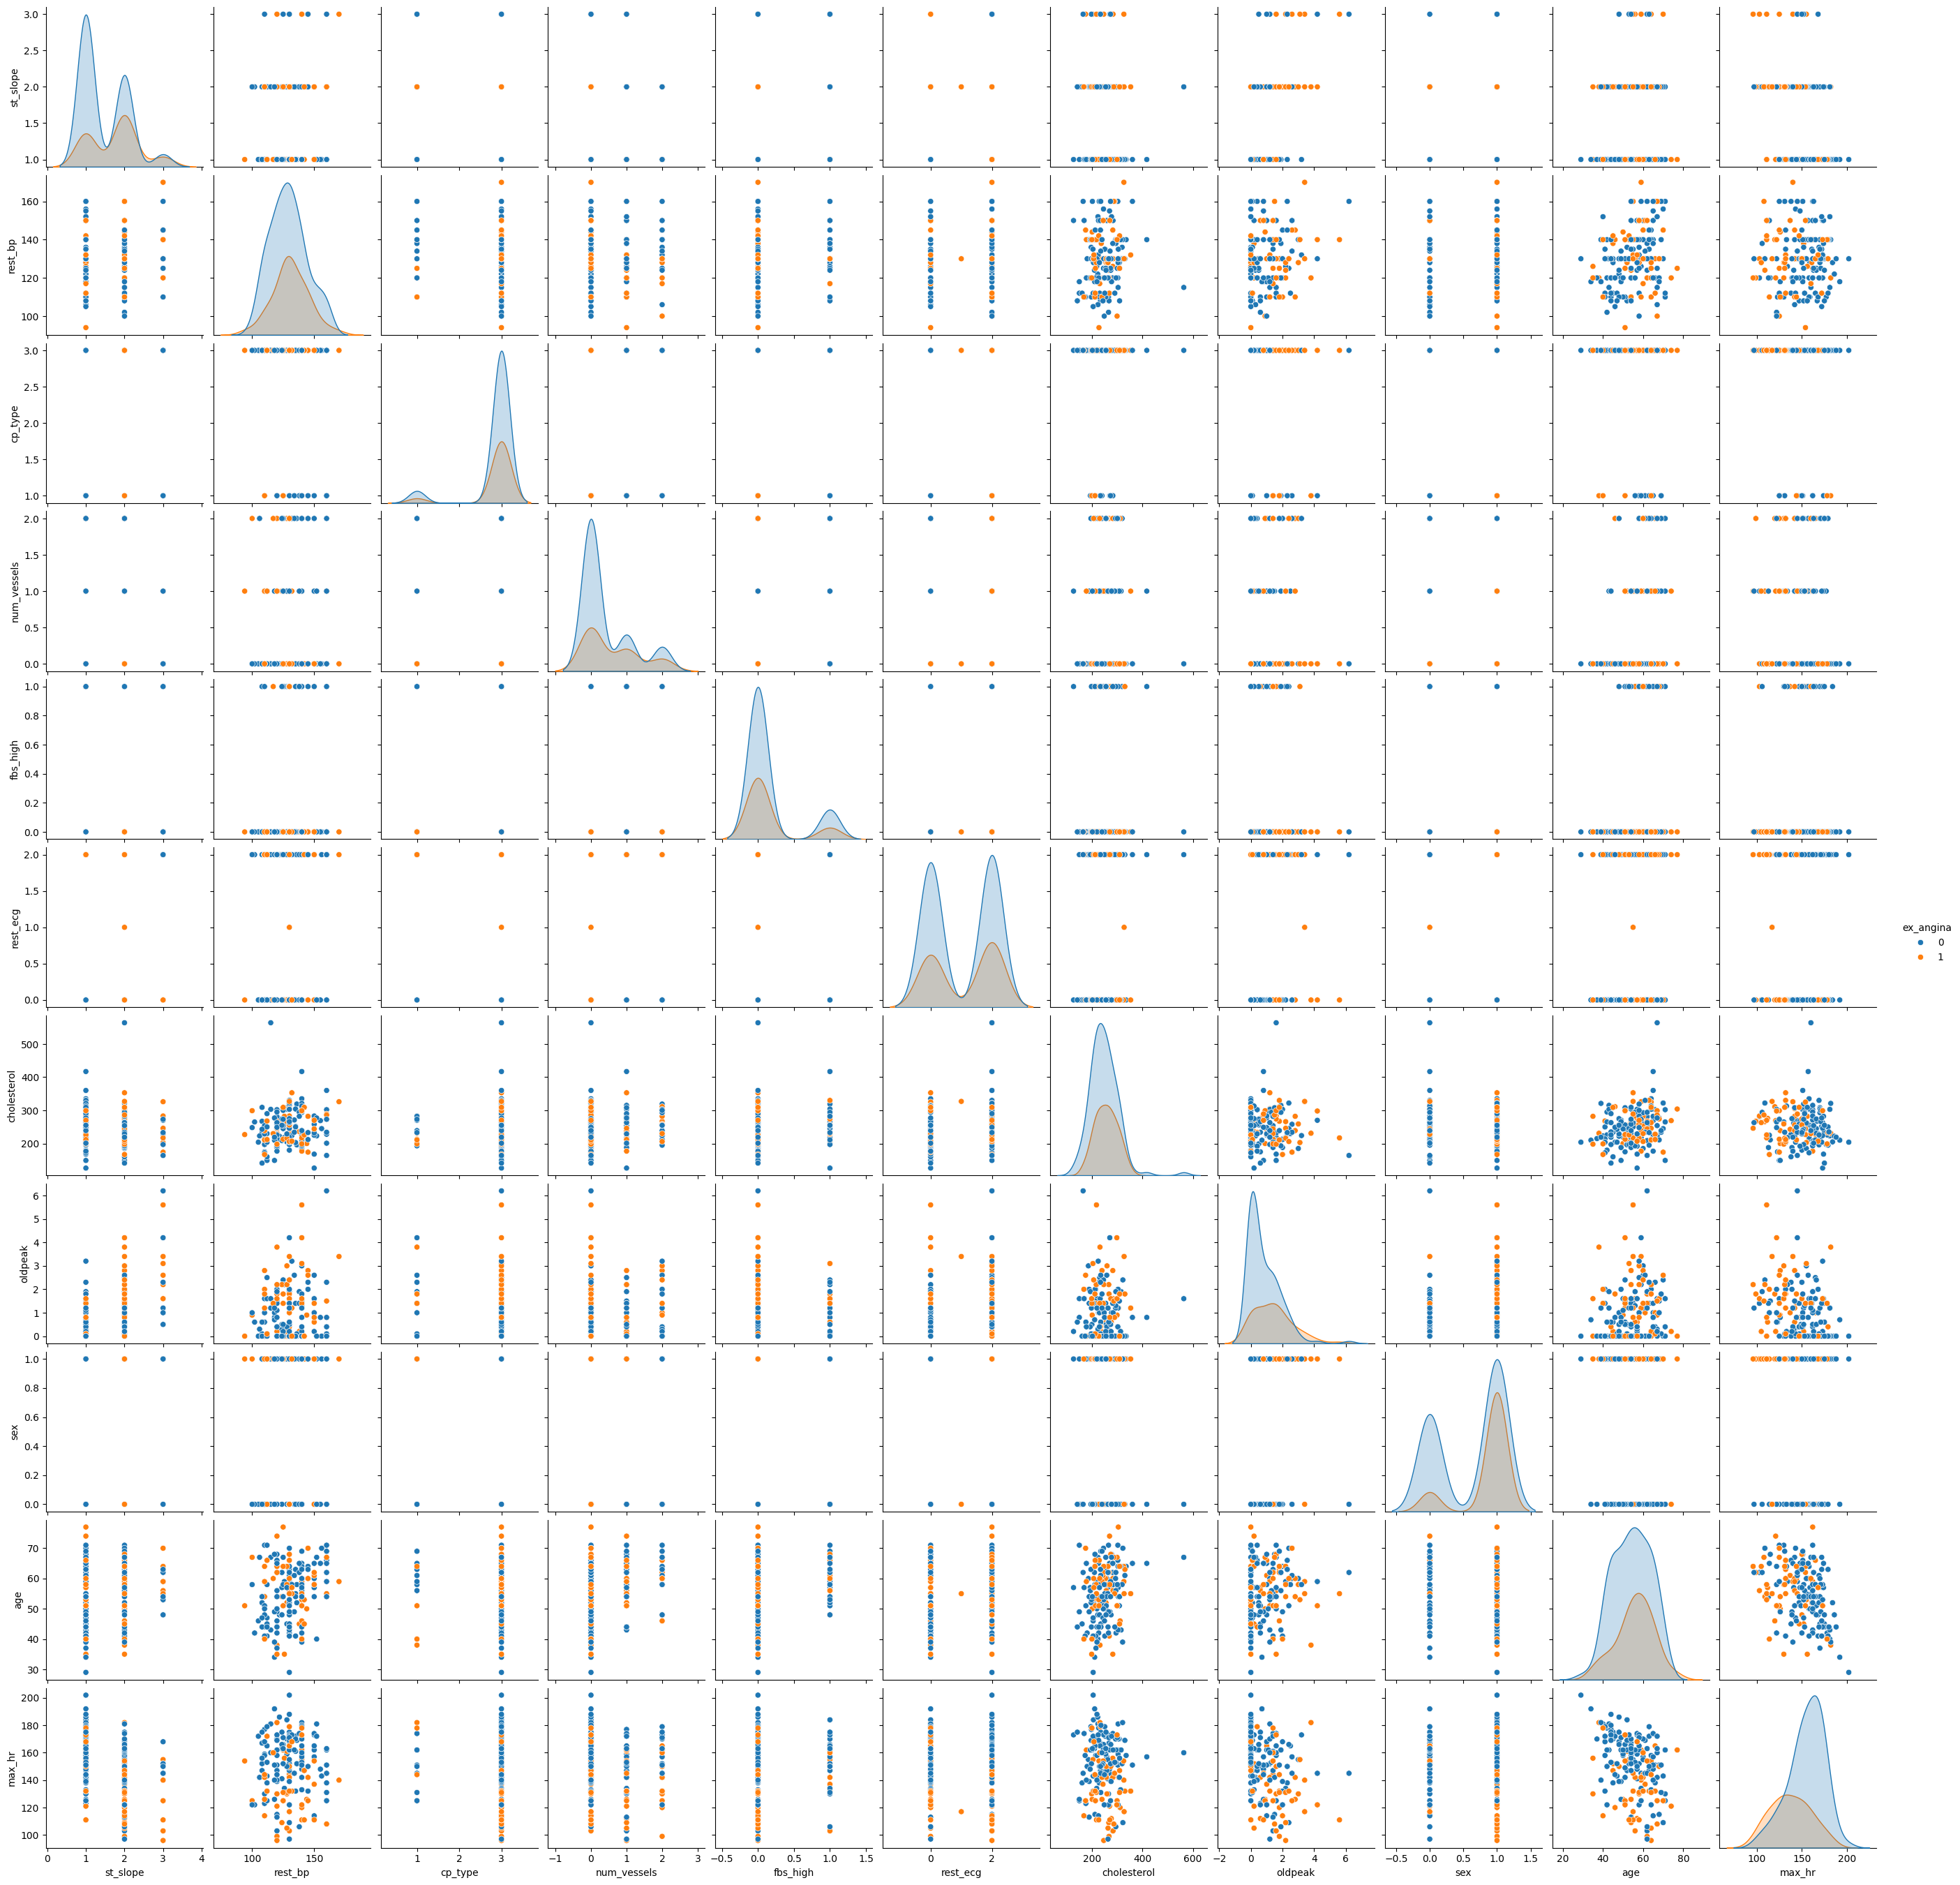

In [ ]:
sns.pairplot(data=data,hue='ex_angina')

In [ ]:
from sklearn.model_selection import train_test_split
y = data['ex_angina']
x = data.drop(columns=['ex_angina', 'patient_id', 'thalassemia'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape

(144, 11)

In [ ]:
x_test.shape

(36, 11)

In [ ]:
y_train.shape

(144,)

In [ ]:
y_test.shape

(36,)

## model fitting

In [ ]:
#Logistic regression

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

In [ ]:
y_pred_lr.shape

(36,)

In [ ]:
score_lr = round(accuracy_score(y_pred_lr,y_test)*100,2)
print("the accuracy score achieved using logistic regression is:"+str(score_lr)+"%")

the accuracy score achieved using logistic regression is:75.0%


## Navie Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train,y_train)

y_pred_nb = nb.predict(x_test)

In [ ]:
y_pred_nb.shape

(36,)

In [ ]:
score_nb=round(accuracy_score(y_pred_nb,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_nb)+"%")

the accuracy score achieved using navie bayes is:80.56%


## svm

In [ ]:
from sklearn.svm import SVC
sv = SVC()
sv.fit(x_train,y_train)
y_pred_sv = sv.predict(x_test)

In [ ]:
y_pred_sv.shape

(36,)

In [ ]:
score_sv=round(accuracy_score(y_pred_sv,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_sv)+"%")

the accuracy score achieved using navie bayes is:72.22%


## Neural network

In [ ]:
from sklearn.neural_network import MLPClassifier
NN = MLPClassifier(hidden_layer_sizes=(10,10,10),max_iter=1000)
NN.fit(x_train,y_train)
y_pred_NN = NN.predict(x_test)

In [ ]:
y_pred_NN.shape

(36,)

In [ ]:
score_NN=round(accuracy_score(y_pred_sv,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_NN)+"%")

the accuracy score achieved using navie bayes is:72.22%


## K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)

In [ ]:
y_pred_knn.shape

(36,)

In [ ]:
score_knn=round(accuracy_score(y_pred_sv,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_knn)+"%")

the accuracy score achieved using navie bayes is:72.22%


## XG boost

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

In [ ]:
y_pred_xgb.shape

(36,)

In [ ]:
score_xgb=round(accuracy_score(y_pred_sv,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_xgb)+"%")

the accuracy score achieved using navie bayes is:72.22%


## Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [ ]:
y_pred_rf.shape

(36,)

In [ ]:
score_rf=round(accuracy_score(y_pred_sv,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_rf)+"%")

the accuracy score achieved using navie bayes is:72.22%


## Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)

In [ ]:
y_pred_dt.shape

(36,)

In [ ]:
score_dt=round(accuracy_score(y_pred_sv,y_test)*100,2)
print("the accuracy score achieved using navie bayes is:"+str(score_dt)+"%")

the accuracy score achieved using navie bayes is:72.22%


## Gradient boosting

In [ ]:
im

## Confusin matrix

In [ ]:
y_prob = rf.predict_proba(x_test)[:, 1]

In [ ]:
threshold = 0.15
y_pred = np.where(y_prob >= threshold, 1, 0)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[ 4 22]
 [ 1  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.15      0.26        26
           1       0.29      0.90      0.44        10

    accuracy                           0.36        36
   macro avg       0.55      0.53      0.35        36
weighted avg       0.66      0.36      0.31        36

ROC-AUC Score: 0.698076923076923


## Output

In [ ]:
scores = [score_lr,score_NN,score_dt,score_knn,score_nb,score_rf,score_sv,score_xgb]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost","Neural Network"]

for i in range(len(algorithms)):
  print("The accuracy score acheieved using"+algorithms[i]+"is:"+str(scores[i])+"%")

The accuracy score acheieved usingLogistic Regressionis:75.0%
The accuracy score acheieved usingNaive Bayesis:72.22%
The accuracy score acheieved usingSupport Vector Machineis:72.22%
The accuracy score acheieved usingK-Nearest Neighborsis:72.22%
The accuracy score acheieved usingDecision Treeis:80.56%
The accuracy score acheieved usingRandom Forestis:72.22%
The accuracy score acheieved usingXGBoostis:72.22%
The accuracy score acheieved usingNeural Networkis:72.22%


<Axes: xlabel='Algorithm', ylabel='Accuracy Score'>

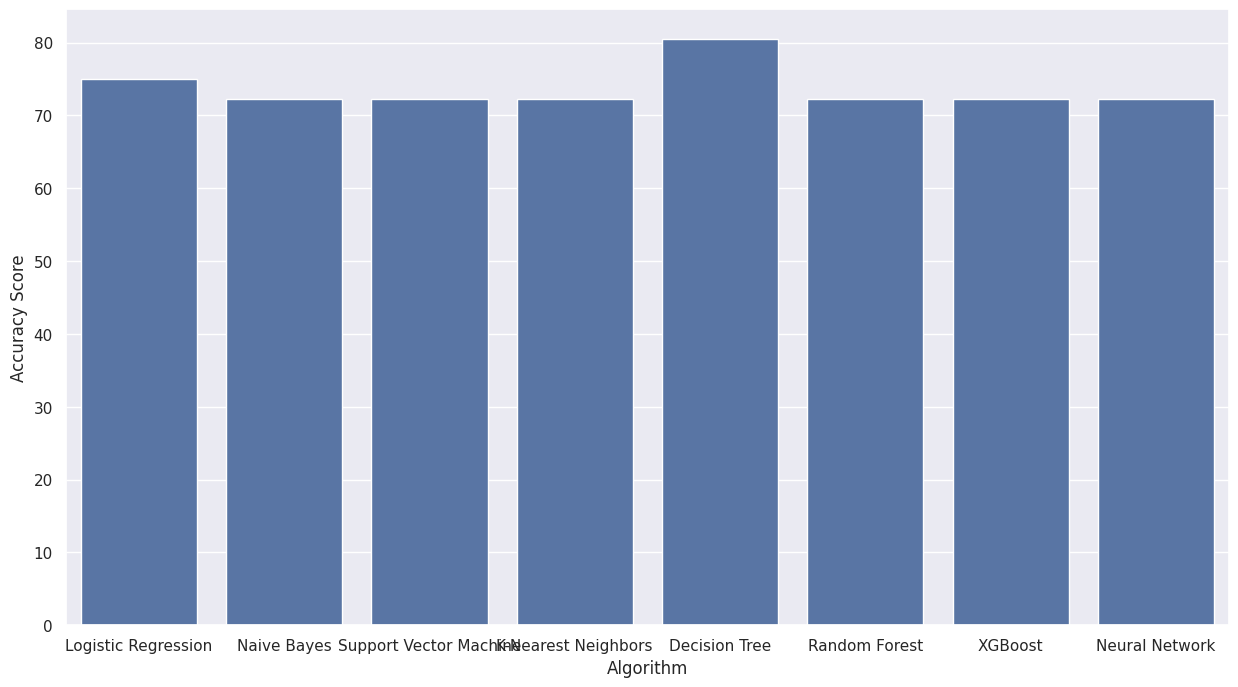

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel('Algorithm')
plt.ylabel('Accuracy Score')
sns.barplot(x=algorithms,y=scores)

# Decision Tree has good results as compared to other algorithms

## Conclusion

 In this Heart disease prediction,i used Machine Learning to predict wheather a person is suffering from a heart disease.After importing the data i analysed it using plots and handle the outliers .Then i applied some machine learning algorithms are logistic regession , naive bayes , svm, k nearest neighbors , neural network , random forest , XG boost , decision tree.i varied parameters across each model to improve their scores,finally Decision Tree achieved the the heighest score of 80.56%